# WR Data Preprocessing & Feature Engineering — Exploration

Walks WR's preprocessing/feature-engineering pipeline one step at a time, materializing
each feature family's intermediate dataframe so it's inspectable on its own -- the same
steps `pipeline.build_position_projections` runs internally, but here every intermediate
is a named variable you can look at, plot, or swap out.

Feature families (see `CONTEXT.md` for the vocabulary, `docs/adr/0015-wr-feature-engineering-round-1.md`
for why WR currently carries Prior-Season Total, Opportunity Vacuum, Own-Team Offensive
Environment, and Per-Touch Efficiency as always-on): trailing team-shares, trailing
per-player averages, snap %, Depth-Chart Competition, Prior-Season Total, Opportunity
Vacuum, Own-Team Offensive Environment, Per-Touch Efficiency. Multi-season memory,
age/experience, and Strength-of-Schedule are wired into the pipeline but currently off
for every position (`docs/research/feature-family-re-sweep-2026-07.md` found them
indistinguishable from noise) -- toggle them back on below to re-check that finding or
try a new variant.

The last section is a sandbox for adding a new candidate feature column, or predicting a
different target stat, without touching `src/ff_model/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from ff_model.depth_chart import depth_chart_competition_history
from ff_model.experience_features import age_history, career_games_history
from ff_model.nflverse import (
    load_draft_picks,
    load_ngs_receiving,
    load_offense_snap_pct,
    load_seasonal_rosters,
    load_team_scores,
    load_weekly_stats,
    pfr_id_crosswalk,
)
from ff_model.opportunity_vacuum import prior_season_points_per_target, vacated_target_share_history
from ff_model.per_touch_efficiency import prior_season_yac_above_expectation_history, prior_season_yards_per_target
from ff_model.pipeline import EARLIEST_SEASON, MIN_CAREER_GAMES
from ff_model.position_config import POSITION_CONFIGS
from ff_model.position_model import add_position_features, feature_columns
from ff_model.team_offensive_environment import team_offensive_environment_by_player, team_offensive_environment_history
from ff_model.veterans import veteran_player_ids

pd.set_option("display.max_columns", None)

TRAIN_THROUGH_SEASON = 2025
config = POSITION_CONFIGS["WR"]
weekly_seasons = list(range(EARLIEST_SEASON, TRAIN_THROUGH_SEASON + 1))
weekly_seasons[:5], weekly_seasons[-3:]

/home/hanan/git/ff26/ff/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


([2006, 2007, 2008, 2009, 2010], [2023, 2024, 2025])

## Step 1 — Raw player-weeks and roster eligibility

`load_weekly_stats` pulls every position's per-player-week box scores (REG season only,
weeks 1-17); we filter to WR here, but note the trailing *team*-share features later need
the all-positions frame too, since a QB scramble or WR jet sweep still counts toward the
team's carries. `veteran_player_ids` applies the Veteran/Rookie split from `CONTEXT.md` --
at least `MIN_CAREER_GAMES` career games strictly before `TRAIN_THROUGH_SEASON`.

In [2]:
weekly_all_positions = load_weekly_stats(weekly_seasons)
weekly = weekly_all_positions.loc[weekly_all_positions["position"] == "WR"]

rosters_all = load_seasonal_rosters(weekly_seasons)
rosters = rosters_all.loc[rosters_all["position"] == "WR"]
eligible = veteran_player_ids(rosters, weekly, season=TRAIN_THROUGH_SEASON, min_career_games=MIN_CAREER_GAMES)

len(weekly), weekly["player_id"].nunique(), len(eligible)

(44140, 1150, 171)

## Step 2 — Depth-Chart Competition history

`depth_chart_competition_history` flags a returning player's (team, position) group as
having gained new offseason competition (free-agent/trade arrival, or a rookie drafted
within `HIGH_DRAFT_PICK_MAX_ROUND`) heading into each season -- mechanically derived from
roster composition, no scheme/fit judgment (`docs/adr/0004-team-context-deferred-except-depth-chart.md`).
It's currently off in WR's default feature set (`include_depth_chart_competition=False` in
`pipeline.build_position_projections`) per the re-sweep, but stays wired into
`add_position_features` below in case you want to flip it back on.

In [3]:
pfr_id_by_player_id = pfr_id_crosswalk(rosters)
snap_pct = load_offense_snap_pct(weekly_seasons, pfr_id_by_player_id)
draft_picks = load_draft_picks(weekly_seasons)

depth_chart_history = depth_chart_competition_history(rosters, draft_picks, weekly_seasons)
depth_chart_history.loc[depth_chart_history["depth_chart_competition"] == 1].head()

,season,player_id,depth_chart_competition
0,2007,00-0001477,True
2,2007,00-0002068,True
3,2007,00-0002099,True
4,2007,00-0004541,True
7,2007,00-0005720,True


## Step 3 — Opportunity Vacuum: departed teammates' vacated target share

`vacated_target_share_history` sums the prior-season target share held by teammates who
left the roster entirely (any reason -- trade, release, retirement, unsigned free agency;
detection is pure roster departure, the same judgment-free standard as Depth-Chart
Competition) but are absent from the target season's roster. Row season `S` sums shares
vacated between `S-1` and `S` (issue #20/#23, `docs/adr/0015-wr-feature-engineering-round-1.md`).
`prior_season_points_per_target` pairs with it: the receiver's own prior-season
`(receiving_yards, receiving_tds, receptions)` scored via `PPR` and divided by targets --
fed as a separate column, not hand-multiplied into the vacated share.

In [4]:
opportunity_vacuum_history = vacated_target_share_history(weekly_all_positions, rosters_all, weekly_seasons)
points_per_target_history = prior_season_points_per_target(weekly_all_positions, weekly_seasons)

opportunity_vacuum_history.sort_values("vacated_target_share", ascending=False).head()

,season,player_id,vacated_target_share
4864,2009,00-0023612,1.0
4869,2009,00-0023622,1.0
4958,2009,00-0024218,1.0
4024,2009,00-0003292,1.0
5329,2009,00-0025591,1.0


## Step 4 — Own-Team Offensive Environment

How much opportunity the player's *own* offense generates, distinct from
Strength-of-Schedule (opponent-side, killed as noise in issue #16):
`team_pass_attempts_per_game`, `team_points_per_game`, `team_passing_ypa`, all from the
prior completed season (issue #24).

In [5]:
team_scores = load_team_scores(weekly_seasons)
team_env_by_team = team_offensive_environment_history(weekly_all_positions, team_scores, weekly_seasons)
team_offensive_environment_history_by_player = team_offensive_environment_by_player(team_env_by_team, rosters)

team_env_by_team.sort_values("team_points_per_game", ascending=False).head()

,season,team,team_pass_attempts_per_game,team_points_per_game,team_passing_ypa
233,2014,DEN,42.1875,37.8750,8.254815
53,2008,NE,36.6250,36.8125,8.291809
399,2019,KC,36.4375,35.3125,8.792453
171,2012,GB,34.4375,35.0000,9.353902
213,2013,NE,40.0625,34.8125,7.556942


## Step 5 — Per-Touch Efficiency

Skill independent of volume: `prior_season_yards_per_target` (own `receiving_yards /
targets` from the immediately preceding season), and `prior_season_yac_above_expectation`
sourced from NGS receiving data (only available from 2016 onward -- earlier seasons carry
NaN here, left as-is per `docs/adr/0015-wr-feature-engineering-round-1.md` rather than
narrowing the backtest window).

In [6]:
ngs_receiving = load_ngs_receiving(weekly_seasons)

yards_per_target_history = prior_season_yards_per_target(weekly_all_positions, weekly_seasons)
yac_history = prior_season_yac_above_expectation_history(ngs_receiving, weekly_seasons)

# add_position_features re-derives prior_season_yards_per_target itself from
# weekly_all_positions -- yac_history (just the NGS-sourced column) is the only piece
# it takes as an argument, shaped like _EMPTY_PER_TOUCH_EFFICIENCY_HISTORY.
yards_per_target_history.merge(yac_history, on=["season", "player_id"], how="left").tail()

,season,player_id,prior_season_yards_per_target,prior_season_yac_above_expectation
7895,2025,00-0039915,10.134615,1.011255
7896,2025,00-0039916,8.710526,-0.208650
7897,2025,00-0039919,7.232323,0.499213
7898,2025,00-0039920,2.666667,NaN
7899,2025,00-0039921,9.833333,NaN


## Step 6 — Assemble the full training table

`add_position_features` runs the always-on process/opportunity features (trailing
team-shares off `config.share_stat_columns`, trailing per-player averages, snap %) plus
every feature-family history built above, then filters down to WR rows. This is the same
call `pipeline.build_position_projections` makes internally -- reproduced here so the
*inputs* to each feature family are visible individually instead of only the merged
result.

In [7]:
training = add_position_features(
    config,
    weekly_all_positions,
    red_zone_carries=pd.DataFrame(columns=["season", "week", "player_id", "red_zone_carries"]),
    snap_pct=snap_pct,
    depth_chart_history=depth_chart_history,
    opportunity_vacuum_history=opportunity_vacuum_history,
    team_offensive_environment_history=team_offensive_environment_history_by_player,
    per_touch_efficiency_history=yac_history,
)
training = training.loc[training["season"] <= TRAIN_THROUGH_SEASON]
training.shape

(44140, 133)

## Step 7 — Feature columns and targets

`feature_columns(config)` is the same helper `position_model.build_position_model_projections`
uses to slice `X_train` -- it's a pure function of `config` plus the ablation toggles
(`include_multi_season`, `experience_feature`, `sos_feature`, `include_depth_chart_competition`),
so calling it here with the defaults reproduces exactly what today's WR model trains on.
`config.raw_stat_columns` are the targets: WR predicts each of these raw stats
independently (a separate quantile model per stat), not fantasy points directly --
`scoring.score_projections` converts to points downstream.

In [8]:
columns = feature_columns(config)
X_train = training[columns]
y_train = training[config.raw_stat_columns]

print(f"{len(columns)} feature columns, {len(config.raw_stat_columns)} target stats")
X_train.head()

17 feature columns, 4 target stats


,trailing_target_share,trailing_air_yards_share,trailing_snap_pct,depth_chart_competition,prior_season_fantasy_points,prior_season_games_played,vacated_target_share,prior_season_points_per_target,team_pass_attempts_per_game,team_points_per_game,team_passing_ypa,prior_season_yards_per_target,prior_season_yac_above_expectation,trailing_avg_targets,trailing_avg_receptions,trailing_avg_receiving_yards,trailing_avg_receiving_tds
21,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Sandbox — try a new feature or a new target

Two common exploration moves:

1. **New candidate feature** — compute it as its own column on `training` (or merge in a
   new history dataframe like the steps above), then add its name to a local copy of
   `columns` before slicing `X_train`. Nothing here touches `src/ff_model/`; promote it
   there only once it looks promising.
2. **New target** — WR's raw-stat targets are `config.raw_stat_columns`
   (`targets`, `receptions`, `receiving_yards`, `receiving_tds`); swap in any other numeric
   column on `training` (e.g. a derived efficiency stat) to see how well the existing
   feature set explains it.

The correlation check below is a first-pass signal only -- it's linear and ignores every
non-linear interaction the RF/LightGBM models actually use, but it's a fast way to eyeball
whether a new column is worth a full backtest.

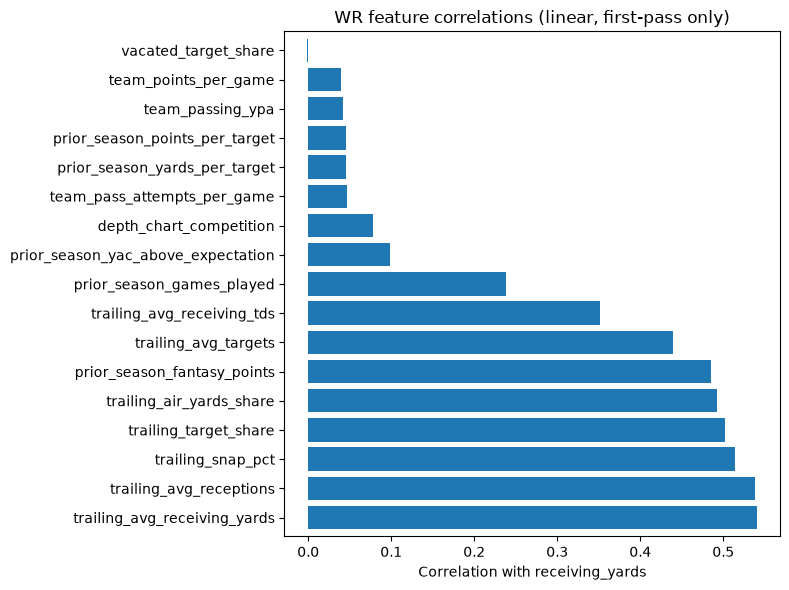

In [9]:
candidate_target = "receiving_yards"  # try swapping this for another config.raw_stat_columns entry

correlations = (
    training[columns + [candidate_target]]
    .corr(numeric_only=True)[candidate_target]
    .drop(candidate_target)
    .sort_values(key=abs, ascending=False)
)

correlations.plot.barh(figsize=(8, 6), width=0.8)
plt.xlabel(f"Correlation with {candidate_target}")
plt.title("WR feature correlations (linear, first-pass only)")
plt.tight_layout()
plt.show()